# Modules & Packages

In [1]:
%load_ext autoreload
%autoreload 2
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import healpy as hp
import glob
import matplotlib
matplotlib.rcParams.update({'font.size':20})
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from pylab import rcParams
from matplotlib import rc;rc('text', usetex=True);rc('font', weight='bold');matplotlib.rcParams['text.latex.preamble']
rcParams['axes.facecolor'] = 'white'
rcParams['font.family'] = 'serif'
rc('text.latex',preamble=r'\usepackage{/sptlocal/user/kevinlevy/summerfield_lensing/notebooks/apjfonts}')
from matplotlib import gridspec
from astropy.io import fits
from astropy.wcs import WCS
from astropy import units as u

import sys, os
sys.path.append("/sptlocal/user/kevinlevy/spt3g_software/build/")
sys.path.append("/sptlocal/user/kevinlevy/spt3g_software/mapspectra/python")
from spt3g import core, maps

# Parameters

In [2]:
freq_arr = [90, 150, 220]
field_arr = ["summer-a", "summer-b", "summer-c"]
nside=2048
lmax = 4000

beam_loc = '/sptlocal/user/kevinlevy/summerfield_lensing/data/beams/'
beam_file = 'compiled_2020_beam_freqghz.npy'

mask_loc = '/sptlocal/user/kevinlevy/summerfield_lensing/data/masks/'
border_mask_file = 'apod_mask_45arcmin_field.fits' #'border_mask_field.fits'
border_mask_dic = {}
for field in field_arr:
    apod_ps_mask = hp.read_map(mask_loc+border_mask_file.replace('field', field))
    apod_ps_mask[apod_ps_mask == hp.UNSEEN] = 0.
    border_mask_dic[field] = apod_ps_mask

ps100mJy_mask_file = 'apod_mask_45arcmin_15arcmin_field_100mJy.fits'
ps100mJy_mask_dic = {}
for field in field_arr:
    apod_ps_mask = hp.read_map(mask_loc+ps100mJy_mask_file.replace('field', field))
    apod_ps_mask[apod_ps_mask == hp.UNSEEN] = 0.
    ps100mJy_mask_dic[field] = apod_ps_mask

ps20mJy_mask_file = 'apod_mask_45arcmin_15arcmin_field_20mJy.fits'
ps20mJy_mask_dic = {}
for field in field_arr:
    apod_ps_mask = hp.read_map(mask_loc+ps20mJy_mask_file.replace('field', field))
    apod_ps_mask[apod_ps_mask == hp.UNSEEN] = 0.
    ps20mJy_mask_dic[field] = apod_ps_mask

data_loc = '/sptlocal/user/kevinlevy/summerfield_lensing/data/coadds/full/maps/fieldname/'
data_file = 'full_coadd.g3.gz'

noise_loc = '/sptlocal/user/kevinlevy/summerfield_lensing/sims/noise/maps/fieldname/full/'
noise_file = 'no_signflip_bundle_000.g3.gz'

cl_theory_loc = '/sptlocal/user/kevinlevy/summerfield_lensing/sims/cmb/spectra/'
cl_theory_file = 'planck2018_base_plikHM_TTTEEE_lowl_lowE_lensing_lensedCls.dat'
ell = np.loadtxt(cl_theory_loc+cl_theory_file, unpack=True)[0][:lmax]
dl_theory = np.loadtxt(cl_theory_loc+cl_theory_file, unpack=True)[1][:lmax]
conv = 2.0*np.pi/(ell**2+ell)
cls_theory = (dl_theory*conv)
dl_fac = 2.0*np.pi/(ell**2+ell)

# for plotting
fontsize = 20
color_arr = ['steelblue', 'goldenrod', 'lightseagreen', 'maroon', 'darkorchid', 'dimgray']  

nbr_pix_dic = {"summer-a":[2200, 1750], "summer-b":[2200, 1750], "summer-c":[3250, 2725]}

cntr_dic = {"summer-a":[75, -46.75], "summer-b":[25, -36], "summer-c":[187.5, -38.5]}  
ra_dic = {'summer-a':[50, 62.5, 75, 87.5, 100], 
          'summer-b':[0, 12.5, 25, 37.5, 50], 
          'summer-c':[150, 168.75, 187.5, 206.25, 225]}
dec_dic = {'summer-a':[-63,-56, -49, -42, -35.875, -31.375, -28.125],            
           'summer-b':[-42, -38.5, -35, -31.5, -28], 
           'summer-c':[-42, -38.5, -35, -31.5, -28]}

reso_arcmin = 1.45 #hp.nside2resol(2048, arcmin = True)
axis_label_arr = [['RA', 'DEC'], ['RA', ' '], ['RA', ' ']] 
origin_arr = ['lower', 'lower', 'lower']
figures_dir = '/sptlocal/user/kevinlevy/summerfield_lensing/figures/data/'

## Beams

In [3]:
beam_dic = {}
for freq in freq_arr:
    beam_dic[freq] = np.load('/sptlocal/user/kevinlevy/summerfield_lensing/data/beams/B_ell.npz')[str(freq)] #np.load(beam_loc+beam_file.replace('freq', str(freq)))

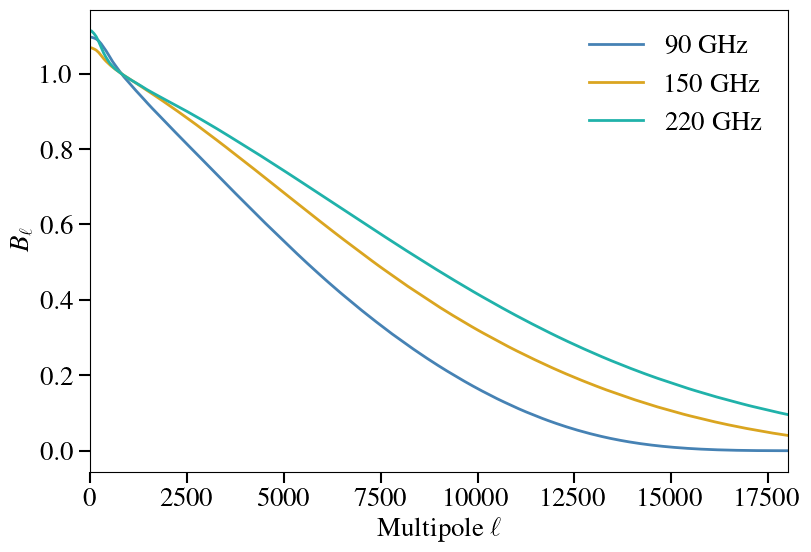

In [4]:
fig, ax = plt.subplots(figsize = (9,6))
for i, freq in enumerate(freq_arr):
    ax.plot(np.arange(len(beam_dic[freq])), beam_dic[freq], label = '%s GHz' %(freq), color=color_arr[i], lw=2)
ax.legend(frameon=False, fontsize=fontsize-0.5)
ax.set_ylabel(r'$B_\ell$'  , fontsize = fontsize-0.5)
ax.set_xlabel('Multipole '+'$\ell$', fontsize = fontsize-0.5)
ax.tick_params(which='major', labelsize = fontsize-0.5, length = 8, width = 1.5)
ax.tick_params(which='minor', labelsize = fontsize-0.5, length = 4, width = 1)
ax.set_xlim(0, 18000)
plt.savefig(figures_dir+'beams.pdf', dpi = 250., bbox_inches = 'tight', pad_inches = 0.1)

## Masks

In [5]:
nbr_pix_dic = {"summer-a":[2100, 1750], "summer-b":[3150, 1140], "summer-c":[3150, 1140]}
border_mask_flatsky_arr = []
for field in field_arr:
    apod_ps_mask_flatsky = hp.gnomview(border_mask_dic[field], xsize=nbr_pix_dic[field][0], ysize=nbr_pix_dic[field][1], rot=(cntr_dic[field][0], cntr_dic[field][1], 0), return_projected_map=True, no_plot=True)
    border_mask_flatsky_arr.append(apod_ps_mask_flatsky) 

ps100mJy_mask_flatsky_arr = []
for field in field_arr:
    apod_ps_mask_flatsky = hp.gnomview(ps100mJy_mask_dic[field], xsize=nbr_pix_dic[field][0], ysize=nbr_pix_dic[field][1], rot=(cntr_dic[field][0], cntr_dic[field][1], 0), return_projected_map=True, no_plot=True)
    ps100mJy_mask_flatsky_arr.append(apod_ps_mask_flatsky) 

ps20mJy_mask_flatsky_arr = []
for field in field_arr:
    apod_ps_mask_flatsky = hp.gnomview(ps20mJy_mask_dic[field], xsize=nbr_pix_dic[field][0], ysize=nbr_pix_dic[field][1], rot=(cntr_dic[field][0], cntr_dic[field][1], 0), return_projected_map=True, no_plot=True)
    ps20mJy_mask_flatsky_arr.append(apod_ps_mask_flatsky) 

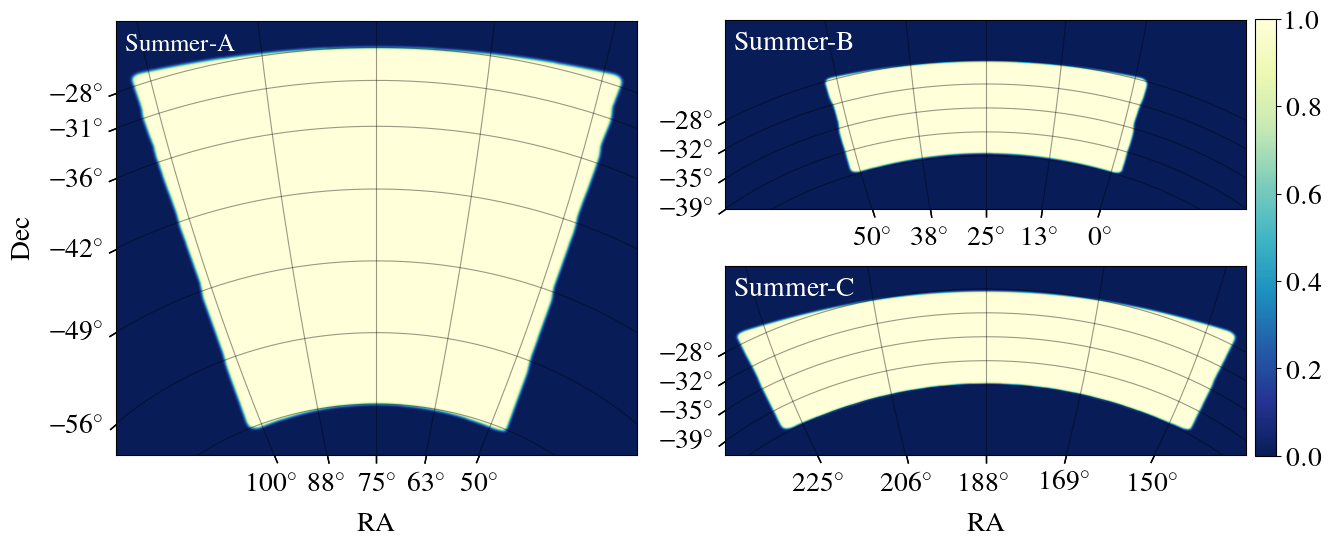

In [6]:
cmap = plt.cm.YlGnBu_r
color_map_dic = {'summer-a':cmap, 'summer-b':cmap, 'summer-c':cmap}
vborder_arr = [[0, 1], [0, 1], [0, 1]]
title_dic = {'summer-a':'Summer-A', 'summer-b':'Summer-B', 'summer-c':'Summer-C'}
label_arr = ['', '', '']
axis_label_arr = [[' RA', 'Dec'], [' ', ' '], ['RA', ' ']] 



cmap.set_bad(color='lightgrey')

fig = plt.figure(figsize=(16, 9))
gs = gridspec.GridSpec(2, 3, width_ratios=[1, 1, 0.04], height_ratios=[1, 1], wspace=0.25, hspace=-0.45) 

for i, field in enumerate(field_arr):

    hdr = fits.Header()
    hdr.set('NAXIS'   , 2)
    hdr.set('NAXIS1'  , nbr_pix_dic[field][0])
    hdr.set('NAXIS2'  , nbr_pix_dic[field][1])
    hdr.set('CTYPE1'  , 'RA---ZEA')
    hdr.set('CRPIX1'  , nbr_pix_dic[field][0]/2)
    hdr.set('CRVAL1'  , cntr_dic[field][0])
    hdr.set('CDELT1'  , -reso_arcmin*0.0166667)
    hdr.set('CUNIT1'  , 'deg')
    hdr.set('CTYPE2'  , 'DEC--ZEA')
    hdr.set('CRPIX2'  , nbr_pix_dic[field][1]/2)
    hdr.set('CRVAL2'  , cntr_dic[field][1]) 
    hdr.set('CDELT2'  , reso_arcmin*0.0166667)
    hdr.set('CUNIT2'  , 'deg')
    hdr.set('COORDSYS','icrs')
        
    w = WCS(hdr)
    if i ==0:
        ax = fig.add_subplot(gs[:, 0], projection=w)
        ax.text(40, 1700, title_dic[field], color='white', fontsize=fontsize-2, fontweight='bold', ha='left', va='top')  
        im0 = ax.imshow(border_mask_flatsky_arr[i], cmap = cmap, vmin=vborder_arr[i][0], vmax=vborder_arr[i][1], origin=origin_arr[i])
    if i ==1:
        ax = fig.add_subplot(gs[0, 1], projection=w)
        ax.text(60, 1080, title_dic[field], color='white', fontsize=fontsize, fontweight='bold', ha='left', va='top') 
    if i ==2:
        ax = fig.add_subplot(gs[1, 1], projection=w)
        ax.text(60, 1080, title_dic[field], color='white', fontsize=fontsize, fontweight='bold', ha='left', va='top') 

    im = ax.imshow(border_mask_flatsky_arr[i], cmap = cmap, vmin=vborder_arr[i][0], vmax=vborder_arr[i][1], origin=origin_arr[i])
    ax.set_xlabel(axis_label_arr[i][0], fontsize = fontsize)
    ax.set_ylabel(axis_label_arr[i][1], fontsize = fontsize)
    
    ax.tick_params(direction='out', axis='x', length=6, width=1, which = 'major', top = False, bottom = True, labelsize = fontsize)
    ax.tick_params(direction='out', axis='y', length=6, width=1, which = 'major', left = True,right = False, labelsize = fontsize)
    ax.grid(color='black', ls='solid',alpha=0.4)
    
    lon, lat = ax.coords
    lat.set_ticklabel_position('l')
    lon.set_ticklabel_position('b')
    lon.set_ticks(ra_dic[field] * u.degree)
    lon.set_major_formatter('dd')
    lat.set_ticks(dec_dic[field] * u.degree)
    lat.set_major_formatter('dd')


cax = fig.add_subplot(gs[:, 2])  

pos = cax.get_position()

cax.set_position([
    pos.x0-0.05,           
    pos.y0+0.1425,    
    pos.width,        
    pos.height*0.631])

cb = fig.colorbar(im0, cax=cax)   
cb.set_label(label=label_arr[-1], fontsize = fontsize)
cb.ax.tick_params(labelsize=fontsize) 


plt.savefig(figures_dir+'border_mask.pdf', dpi = 250., bbox_inches = 'tight', pad_inches = 0.1)

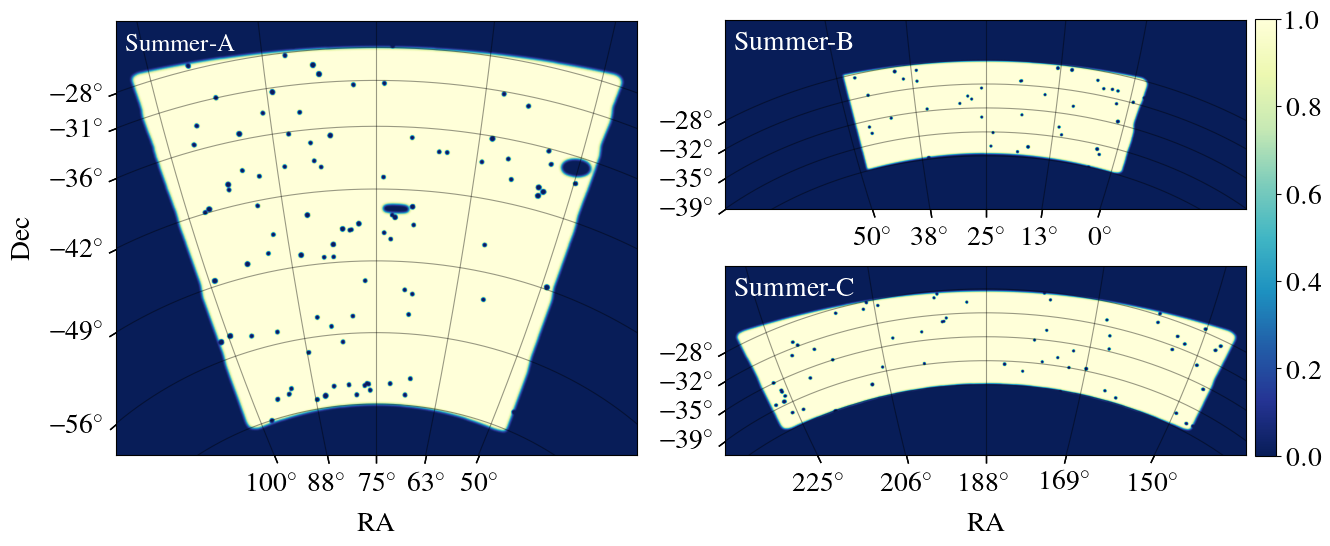

In [7]:
cmap = plt.cm.YlGnBu_r
color_map_dic = {'summer-a':cmap, 'summer-b':cmap, 'summer-c':cmap}
vborder_arr = [[0, 1], [0, 1], [0, 1]]
title_dic = {'summer-a':'Summer-A', 'summer-b':'Summer-B', 'summer-c':'Summer-C'}
label_arr = ['', '', '']
axis_label_arr = [[' RA', 'Dec'], [' ', ' '], ['RA', ' ']] 



cmap.set_bad(color='lightgrey')

fig = plt.figure(figsize=(16, 9))
gs = gridspec.GridSpec(2, 3, width_ratios=[1, 1, 0.04], height_ratios=[1, 1], wspace=0.25, hspace=-0.45) 

for i, field in enumerate(field_arr):

    hdr = fits.Header()
    hdr.set('NAXIS'   , 2)
    hdr.set('NAXIS1'  , nbr_pix_dic[field][0])
    hdr.set('NAXIS2'  , nbr_pix_dic[field][1])
    hdr.set('CTYPE1'  , 'RA---ZEA')
    hdr.set('CRPIX1'  , nbr_pix_dic[field][0]/2)
    hdr.set('CRVAL1'  , cntr_dic[field][0])
    hdr.set('CDELT1'  , -reso_arcmin*0.0166667)
    hdr.set('CUNIT1'  , 'deg')
    hdr.set('CTYPE2'  , 'DEC--ZEA')
    hdr.set('CRPIX2'  , nbr_pix_dic[field][1]/2)
    hdr.set('CRVAL2'  , cntr_dic[field][1]) 
    hdr.set('CDELT2'  , reso_arcmin*0.0166667)
    hdr.set('CUNIT2'  , 'deg')
    hdr.set('COORDSYS','icrs')
        
    w = WCS(hdr)
    if i ==0:
        ax = fig.add_subplot(gs[:, 0], projection=w)
        ax.text(40, 1700, title_dic[field], color='white', fontsize=fontsize-2, fontweight='bold', ha='left', va='top')  
        im0 = ax.imshow(ps100mJy_mask_flatsky_arr[i], cmap = cmap, vmin=vborder_arr[i][0], vmax=vborder_arr[i][1], origin=origin_arr[i])
    if i ==1:
        ax = fig.add_subplot(gs[0, 1], projection=w)
        ax.text(60, 1080, title_dic[field], color='white', fontsize=fontsize, fontweight='bold', ha='left', va='top') 
    if i ==2:
        ax = fig.add_subplot(gs[1, 1], projection=w)
        ax.text(60, 1080, title_dic[field], color='white', fontsize=fontsize, fontweight='bold', ha='left', va='top') 

    im = ax.imshow(ps100mJy_mask_flatsky_arr[i], cmap = cmap, vmin=vborder_arr[i][0], vmax=vborder_arr[i][1], origin=origin_arr[i])
    ax.set_xlabel(axis_label_arr[i][0], fontsize = fontsize)
    ax.set_ylabel(axis_label_arr[i][1], fontsize = fontsize)
    
    ax.tick_params(direction='out', axis='x', length=6, width=1, which = 'major', top = False, bottom = True, labelsize = fontsize)
    ax.tick_params(direction='out', axis='y', length=6, width=1, which = 'major', left = True,right = False, labelsize = fontsize)
    ax.grid(color='black', ls='solid',alpha=0.4)
    
    lon, lat = ax.coords
    lat.set_ticklabel_position('l')
    lon.set_ticklabel_position('b')
    lon.set_ticks(ra_dic[field] * u.degree)
    lon.set_major_formatter('dd')
    lat.set_ticks(dec_dic[field] * u.degree)
    lat.set_major_formatter('dd')


cax = fig.add_subplot(gs[:, 2])  

pos = cax.get_position()

cax.set_position([
    pos.x0-0.05,           
    pos.y0+0.1425,    
    pos.width,        
    pos.height*0.631])

cb = fig.colorbar(im0, cax=cax)   
cb.set_label(label=label_arr[-1], fontsize = fontsize)
cb.ax.tick_params(labelsize=fontsize) 

#plt.savefig(figures_dir+'border_ps_mask_100mJy.pdf', dpi = 250., bbox_inches = 'tight', pad_inches = 0.1)

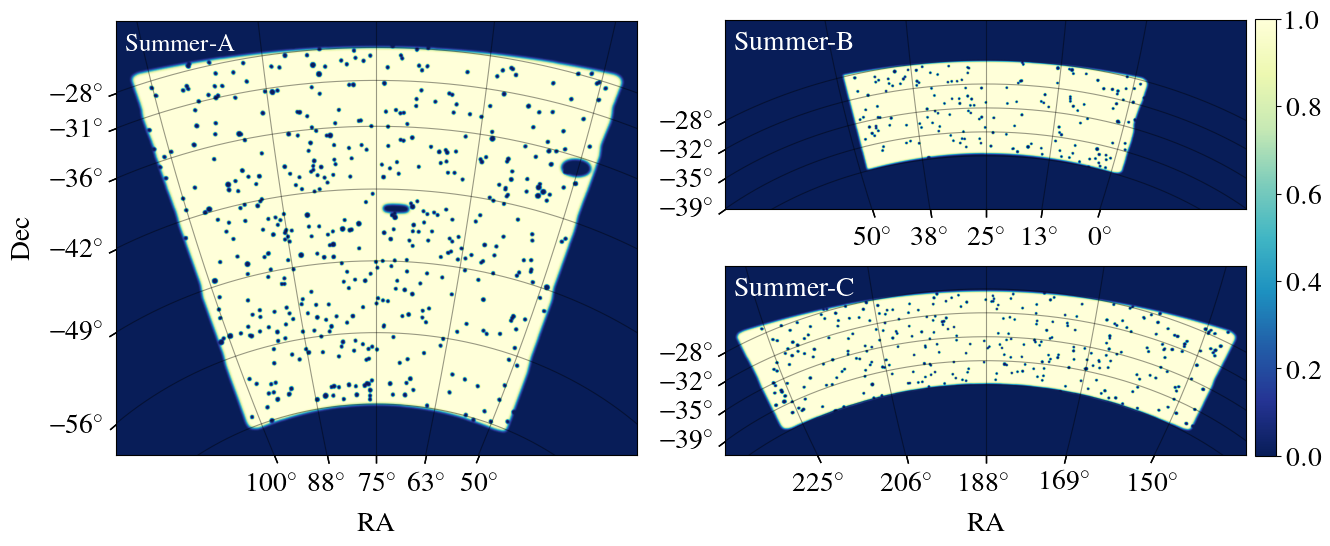

In [8]:
cmap = plt.cm.YlGnBu_r
color_map_dic = {'summer-a':cmap, 'summer-b':cmap, 'summer-c':cmap}
vborder_arr = [[0, 1], [0, 1], [0, 1]]
title_dic = {'summer-a':'Summer-A', 'summer-b':'Summer-B', 'summer-c':'Summer-C'}
label_arr = ['', '', '']
axis_label_arr = [[' RA', 'Dec'], [' ', ' '], ['RA', ' ']] 



cmap.set_bad(color='lightgrey')

fig = plt.figure(figsize=(16, 9))
gs = gridspec.GridSpec(2, 3, width_ratios=[1, 1, 0.04], height_ratios=[1, 1], wspace=0.25, hspace=-0.45) 

for i, field in enumerate(field_arr):

    hdr = fits.Header()
    hdr.set('NAXIS'   , 2)
    hdr.set('NAXIS1'  , nbr_pix_dic[field][0])
    hdr.set('NAXIS2'  , nbr_pix_dic[field][1])
    hdr.set('CTYPE1'  , 'RA---ZEA')
    hdr.set('CRPIX1'  , nbr_pix_dic[field][0]/2)
    hdr.set('CRVAL1'  , cntr_dic[field][0])
    hdr.set('CDELT1'  , -reso_arcmin*0.0166667)
    hdr.set('CUNIT1'  , 'deg')
    hdr.set('CTYPE2'  , 'DEC--ZEA')
    hdr.set('CRPIX2'  , nbr_pix_dic[field][1]/2)
    hdr.set('CRVAL2'  , cntr_dic[field][1]) 
    hdr.set('CDELT2'  , reso_arcmin*0.0166667)
    hdr.set('CUNIT2'  , 'deg')
    hdr.set('COORDSYS','icrs')
        
    w = WCS(hdr)
    if i ==0:
        ax = fig.add_subplot(gs[:, 0], projection=w)
        ax.text(40, 1700, title_dic[field], color='white', fontsize=fontsize-2, fontweight='bold', ha='left', va='top')  
        im0 = ax.imshow(ps20mJy_mask_flatsky_arr[i], cmap = cmap, vmin=vborder_arr[i][0], vmax=vborder_arr[i][1], origin=origin_arr[i])
    if i ==1:
        ax = fig.add_subplot(gs[0, 1], projection=w)
        ax.text(60, 1080, title_dic[field], color='white', fontsize=fontsize, fontweight='bold', ha='left', va='top') 
    if i ==2:
        ax = fig.add_subplot(gs[1, 1], projection=w)
        ax.text(60, 1080, title_dic[field], color='white', fontsize=fontsize, fontweight='bold', ha='left', va='top') 

    im = ax.imshow(ps20mJy_mask_flatsky_arr[i], cmap = cmap, vmin=vborder_arr[i][0], vmax=vborder_arr[i][1], origin=origin_arr[i])
    ax.set_xlabel(axis_label_arr[i][0], fontsize = fontsize)
    ax.set_ylabel(axis_label_arr[i][1], fontsize = fontsize)
    
    ax.tick_params(direction='out', axis='x', length=6, width=1, which = 'major', top = False, bottom = True, labelsize = fontsize)
    ax.tick_params(direction='out', axis='y', length=6, width=1, which = 'major', left = True,right = False, labelsize = fontsize)
    ax.grid(color='black', ls='solid',alpha=0.4)
    
    lon, lat = ax.coords
    lat.set_ticklabel_position('l')
    lon.set_ticklabel_position('b')
    lon.set_ticks(ra_dic[field] * u.degree)
    lon.set_major_formatter('dd')
    lat.set_ticks(dec_dic[field] * u.degree)
    lat.set_major_formatter('dd')


cax = fig.add_subplot(gs[:, 2])  

pos = cax.get_position()

cax.set_position([
    pos.x0-0.05,           
    pos.y0+0.1425,    
    pos.width,        
    pos.height*0.631])

cb = fig.colorbar(im0, cax=cax)   
cb.set_label(label=label_arr[-1], fontsize = fontsize)
cb.ax.tick_params(labelsize=fontsize) 

plt.savefig(figures_dir+'border_ps_mask_20mJy.pdf', dpi = 250., bbox_inches = 'tight', pad_inches = 0.1)

In [9]:
for field in field_arr:
    print(np.mean(border_mask_dic[field]**2)* 41252.96)
    print(np.mean(ps20mJy_mask_dic[field]**2)* 41252.96)
    fraction_lost = np.mean(border_mask_dic[field]**2) - np.mean(ps20mJy_mask_dic[field]**2)
    area_lost_deg2 = fraction_lost * 41252.96
    area_full = np.mean(border_mask_dic[field]**2) * 41252.96
    print(100*area_lost_deg2/area_full)

1252.520543549589
1165.3090130486084
6.962882241741665
581.8411722264682
523.7372488196952
9.986217232519476
855.4378453453811
807.3121867504977
5.625851002120767


## Coadds

### Full

In [10]:
def read_map(f, band, debug = False):
    m = core.G3File(f)
    for frame in m:
        if frame.type != core.G3FrameType.Map: continue
        if frame['Id'] != band: continue
        if debug: print(frame)
        return frame

nbr_pix_dic = {"summer-a":[2100, 1750], "summer-b":[3150, 1140], "summer-c":[3150, 1140]}
tmap_arr = []
for field in field_arr:      
    mapframe = read_map((data_loc+data_file).replace('fieldname', field), band='%sGHz'%(150))
    maps.RemoveWeights( mapframe, zero_nans = True )
    tmap = np.asarray(mapframe['T'])*ps20mJy_mask_dic[field]
    tmap_arr.append(hp.gnomview(tmap*1e3, xsize=nbr_pix_dic[field][0], ysize=nbr_pix_dic[field][1], rot=(cntr_dic[field][0], cntr_dic[field][1], 0), return_projected_map=True, no_plot=True))

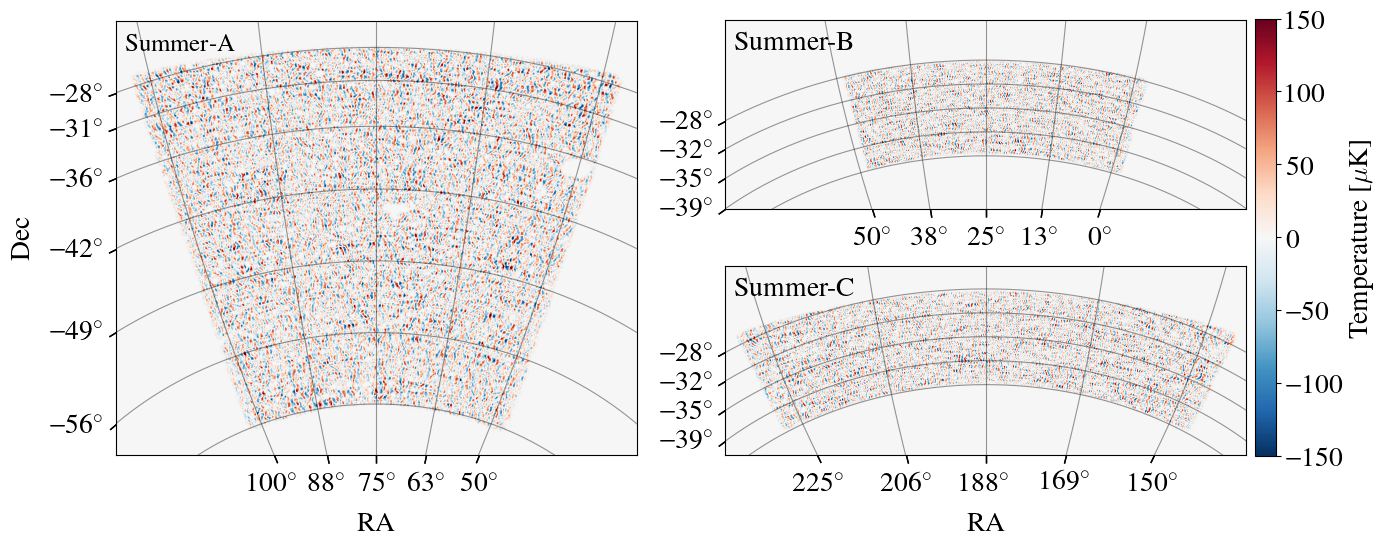

In [11]:
color_map_dic = {'summer-a':cm.RdBu_r, 'summer-b':cm.RdBu_r, 'summer-c':cm.RdBu_r}
vborder_arr = [[-150, 150], [-150, 150], [-150, 150]]
title_dic = {'summer-a':'Summer-A', 'summer-b':'Summer-B', 'summer-c':'Summer-C'}
label_arr = ['', '', 'Temperature ' + r'[$\mu$K]']
axis_label_arr = [[' RA', 'Dec'], [' ', ' '], ['RA', ' ']] 


cmap = cm.RdBu_r
cmap.set_bad(color='lightgrey')

fig = plt.figure(figsize=(16, 9))
gs = gridspec.GridSpec(2, 3, width_ratios=[1, 1, 0.04], height_ratios=[1, 1], wspace=0.25, hspace=-0.45) 

for i, field in enumerate(field_arr):

    hdr = fits.Header()
    hdr.set('NAXIS'   , 2)
    hdr.set('NAXIS1'  , nbr_pix_dic[field][0])
    hdr.set('NAXIS2'  , nbr_pix_dic[field][1])
    hdr.set('CTYPE1'  , 'RA---ZEA')
    hdr.set('CRPIX1'  , nbr_pix_dic[field][0]/2)
    hdr.set('CRVAL1'  , cntr_dic[field][0])
    hdr.set('CDELT1'  , -reso_arcmin*0.0166667)
    hdr.set('CUNIT1'  , 'deg')
    hdr.set('CTYPE2'  , 'DEC--ZEA')
    hdr.set('CRPIX2'  , nbr_pix_dic[field][1]/2)
    hdr.set('CRVAL2'  , cntr_dic[field][1]) 
    hdr.set('CDELT2'  , reso_arcmin*0.0166667)
    hdr.set('CUNIT2'  , 'deg')
    hdr.set('COORDSYS','icrs')
        
    w = WCS(hdr)
    if i ==0:
        ax = fig.add_subplot(gs[:, 0], projection=w)
        ax.text(40, 1700, title_dic[field], color='black', fontsize=fontsize-2, fontweight='bold', ha='left', va='top')  
        im0 = ax.imshow(tmap_arr[i], cmap = cm.RdBu_r, vmin=vborder_arr[i][0], vmax=vborder_arr[i][1], origin=origin_arr[i])
    if i ==1:
        ax = fig.add_subplot(gs[0, 1], projection=w)
        ax.text(60, 1080, title_dic[field], color='black', fontsize=fontsize, fontweight='bold', ha='left', va='top') 
    if i ==2:
        ax = fig.add_subplot(gs[1, 1], projection=w)
        ax.text(60, 1080, title_dic[field], color='black', fontsize=fontsize, fontweight='bold', ha='left', va='top') 

    im = ax.imshow(tmap_arr[i], cmap = cm.RdBu_r, vmin=vborder_arr[i][0], vmax=vborder_arr[i][1], origin=origin_arr[i])
    ax.set_xlabel(axis_label_arr[i][0], fontsize = fontsize)
    ax.set_ylabel(axis_label_arr[i][1], fontsize = fontsize)
    
    ax.tick_params(direction='out', axis='x', length=6, width=1, which = 'major', top = False, bottom = True, labelsize = fontsize)
    ax.tick_params(direction='out', axis='y', length=6, width=1, which = 'major', left = True,right = False, labelsize = fontsize)
    ax.grid(color='black', ls='solid',alpha=0.4)
    
    lon, lat = ax.coords
    lat.set_ticklabel_position('l')
    lon.set_ticklabel_position('b')
    lon.set_ticks(ra_dic[field] * u.degree)
    lon.set_major_formatter('dd')
    lat.set_ticks(dec_dic[field] * u.degree)
    lat.set_major_formatter('dd')


cax = fig.add_subplot(gs[:, 2])  

pos = cax.get_position()

cax.set_position([
    pos.x0-0.05,           
    pos.y0+0.1425,    
    pos.width,        
    pos.height*0.631])

cb = fig.colorbar(im0, cax=cax)   
cb.set_label(label=label_arr[-1], fontsize = fontsize)
cb.ax.tick_params(labelsize=fontsize) 

plt.savefig(figures_dir+'temperature_maps.pdf', dpi = 250., bbox_inches = 'tight', pad_inches = 0.1)

In [12]:
%%script false --no-raise-error
def read_map_frame(path, id=None):
    if not os.path.exists(path):
        raise OSError("File {} does not exist".format(path))

    if path.split(".")[-1] == 'g3' or path.split(".")[-1] == 'gz': 
        for frame in core.G3File(path): 
            if frame.type == core.G3FrameType.Map and frame['Id']==id:
                return frame
        raise RuntimeError("Map frame {} not found G3File.".format(id))
    elif path.split(".")[-1] == 'fits':
        return maps.fitsio.load_skymap_fits(path)
    raise OSError("G3File {} does not contain a map frame .".format(path))


def read_map(path, id=None):
    for frame in core.G3File(path): 
        return frame["T"]

import curved_sky 

def get_cl_from_polspice(m1, m2 = None, mask = None, bl1 = None, bl2 = None, 
                         lmin = 0, lmax = 4096, bin_width = 1, 
                         return_mask = False, return_error = False, return_kernel = False,
                         pixwin = 'NO', pixwin_lab = 'False', lfac = 0, 
                         verbose = True, symmetric_cl = 0, apodizetype = 1, 
                         apodizesigma = 30, thetamax = 30, tolerance = 1.e-08):
    
    binned_el, binned_cl = curved_sky.spectrum_spice(
            map1=m1, 
            map2=m2, 
            lmin=lmin, 
            lmax=lmax, 
            bin_width=bin_width,
            return_mask=return_mask,
            mask=mask,
            return_error=return_error,
            return_kernel=return_kernel, 
            lfac=lfac, 
            verbose=verbose,
            beam=bl1,
            pixwin=pixwin,
            beam2=bl2,
            pixwin2=pixwin,
            symmetric_cl=symmetric_cl,
            apodizetype=apodizetype,
            apodizesigma=apodizesigma,
            thetamax=thetamax,
            tolerance=tolerance)

    return binned_el, binned_cl

field_arr = ['summer-a', 'summer-b', 'summer-c']

tmap_dic = {}
for field in field_arr:
    tmap_dic[field] = {}
    for freq in freq_arr:
        data = read_map_frame((data_loc+data_file).replace('fieldname', field), id='%sGHz'%(freq))
        maps.RemoveWeights(data, zero_nans=True)
        t_map = np.asarray(data["T"])*1e3  
        ps_map = np.asarray(read_map('/sptlocal/user/kevinlevy/summerfield_lensing/sims/mocks/coadds/maps/coadd_point_source_map_6.0to5000.0mJy_%sghz.g3'%(freq)))
        binned_el, binned_cl = get_cl_from_polspice((t_map-ps_map)*ps20mJy_mask_dic[field], mask = ps20mJy_mask_dic[field])
        np.save('/sptlocal/user/kevinlevy/summerfield_lensing/data/coadds/full/spectra/%s/cls_%sghz_%sghz.npy'%(field, freq, freq), binned_cl)      

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


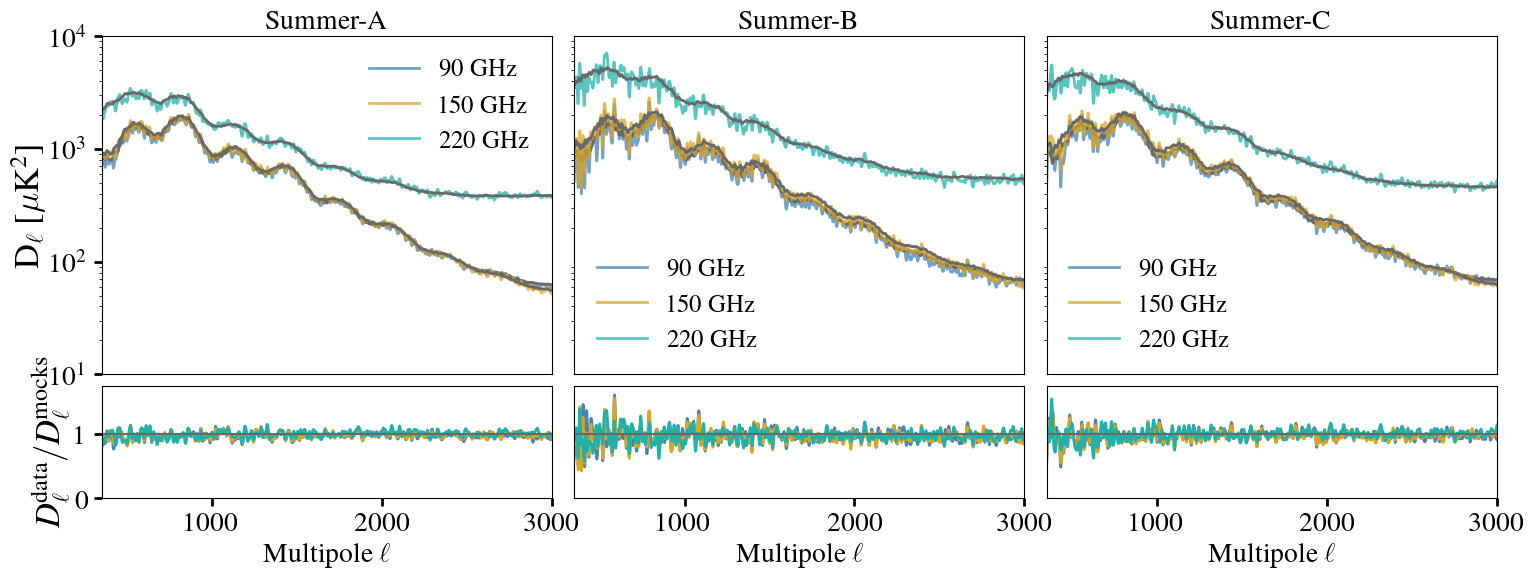

In [13]:
nside=2048
lmax = 2 * nside 
pixwin = hp.pixwin(8192)[:lmax]
summer_field_arr2 = ['summera', 'summerb', 'summerc']
fig, ax_arr = plt.subplots(ncols=3, nrows=2, figsize = (18,6), constrained_layout=True, gridspec_kw={'height_ratios':[3,1]}) 
plt.subplots_adjust(hspace=0.05, wspace=0.05)
tf1d = np.load("/sptlocal/user/kevinlevy/summerfield_lensing/sims/mocks/tfs/summer-a/tf1d_150ghz_100sims.npy")[:lmax]

for cntr, field in enumerate(field_arr):
    for frq_cntr, freq in enumerate(freq_arr):   
        blv2 = np.load('/sptlocal/user/kevinlevy/summerfield_lensing/data/beams/compiled_2020_beam_%sghz.npy'%(freq))[:lmax]
        blv4 = np.load('/sptlocal/user/kevinlevy/summerfield_lensing/data/beams/B_ell.npz')[str(freq)][:lmax]

        curr_binned_cl =  np.load('/sptlocal/user/kevinlevy/summerfield_lensing/data/coadds/full/spectra/%s/cls_%sghz_%sghz.npy'%(field, freq, freq))[:lmax]       
        binned_el = np.arange(len(curr_binned_cl))
        binned_dl_fac = binned_el * (binned_el+1)/2/np.pi
        
        ax_arr[0][cntr].plot(binned_el[:lmax], binned_dl_fac[:lmax] * (curr_binned_cl)/blv4**2, lw=2, color = color_arr[frq_cntr], label =  str(freq)+' GHz', alpha=0.75)
        
        cls_arr = []
        for i in range(1, 16):    
            cls_mock = np.load('/sptlocal/user/kevinlevy/summerfield_lensing/sims/mocks/coadds/spectra/cls_tqu1_agora0.7_datamatched_mcmccal_0707231033_%s_%sghz_%sghz_seed%s.npy'%(summer_field_arr2[cntr], freq, freq, i))[0]
            cls_arr.append(cls_mock)   
        nl = np.load('/sptlocal/user/kevinlevy/summerfield_lensing/sims/noise/spectra/%s/full/cls_%sghz_%sghz_avg100.npy'%(field, freq, freq))[:lmax]
        cls_sim = np.mean(cls_arr,axis=0)[:lmax]+nl
        ax_arr[0][cntr].plot(binned_el[:lmax], binned_dl_fac[:lmax]*cls_sim/blv2**2/pixwin**2, lw=2, color = color_arr[-1])
    ax_arr[0][cntr].tick_params(labelsize = fontsize, length = 6, width = 2)
    ax_arr[0][cntr].tick_params(axis='x', which='both', bottom=False, top=False, labelbottom=False)     
    ax_arr[0][cntr].set_yscale('log')
    ax_arr[0][cntr].set_xlim(350, 3000) 
    ax_arr[0][cntr].legend(fontsize=fontsize-2, frameon=False)
    ax_arr[0][cntr].set_title(title_dic[field], fontsize=fontsize) 
    ax_arr[0][cntr].set_ylim(1e1, 1e4)
    if cntr==0:        
        ax_arr[0][cntr].set_ylabel(r'D$_{\ell}$ [$\mu$K$^{2}$]', fontsize=fontsize+5)
    else:
        ax_arr[0][cntr].tick_params(direction='out', axis='y', length=6, width=2, which = 'major', left = False, right = False, labelsize = fontsize, labelleft=False)

for cntr, field in enumerate(field_arr):
    for frq_cntr, freq in enumerate(freq_arr):    
        blv2 = np.load('/sptlocal/user/kevinlevy/summerfield_lensing/data/beams/compiled_2020_beam_%sghz.npy'%(freq))[:lmax]
        blv4 = np.load('/sptlocal/user/kevinlevy/summerfield_lensing/data/beams/B_ell.npz')[str(freq)][:lmax]

        curr_binned_cl =  np.load('/sptlocal/user/kevinlevy/summerfield_lensing/data/coadds/full/spectra/%s/cls_%sghz_%sghz.npy'%(field, freq, freq))[:lmax]       
        binned_dl_fac = binned_el * (binned_el+1)/2/np.pi
        
        cls_arr = []
        for i in range(1, 16):    
            cls_mock = np.load('/sptlocal/user/kevinlevy/summerfield_lensing/sims/mocks/coadds/spectra/cls_tqu1_agora0.7_datamatched_mcmccal_0707231033_%s_%sghz_%sghz_seed%s.npy'%(summer_field_arr2[cntr], freq, freq, i))[0]
            cls_arr.append(cls_mock)   
        nl = np.load('/sptlocal/user/kevinlevy/summerfield_lensing/sims/noise/spectra/%s/full/cls_%sghz_%sghz_avg100.npy'%(field, freq, freq))[:lmax]
        cls_sim = np.mean(cls_arr,axis=0)[:lmax]+nl
        ax_arr[1][cntr].plot(binned_el[:lmax], (curr_binned_cl/cls_sim[:lmax])*(blv2**2*pixwin**2)/blv4**2, lw=2, color = color_arr[frq_cntr])
    
    ax_arr[1][cntr].tick_params(labelsize = fontsize, length = 6, width = 2)    
    ax_arr[1][cntr].axhline(1, color=color_arr[-1])
    ax_arr[1][cntr].set_xlim(350, 3000) 
    ax_arr[1][cntr].set_xlabel(r'Multipole $\ell$', fontsize=fontsize)
    ax_arr[1][cntr].legend(fontsize=fontsize-2, frameon=False)
    ax_arr[1][cntr].set_ylim(0., 1.75)
    if cntr==0:
        ax_arr[1][cntr].set_ylabel(r'$D_\ell^{\rm data}/D_\ell^{\rm mocks}$', fontsize=fontsize+5)
    else:
        ax_arr[1][cntr].tick_params(direction='out', axis='y', length=6, width=2, which = 'major', left = False, right = False, labelsize = fontsize, labelleft=False)        

plt.savefig(figures_dir+'data_spectra.pdf', dpi = 250., bbox_inches = 'tight', pad_inches = 0.1)

### Noise

In [14]:
%%script false --no-raise-error
import curved_sky 

def read_map_frame(path, id):
    if path.split(".")[-1] == 'g3' or path.split(".")[-1] == 'gz': 
        for frame in core.G3File(path): 
            if frame['Id'] == str(freq)+"GHz":
                print(frame)
                return frame


def get_cl_from_polspice(m1, m2 = None, mask = None, bl1 = None, bl2 = None, 
                         lmin = 0, lmax = 4096, bin_width = 1, 
                         return_mask = False, return_error = False, return_kernel = False,
                         pixwin = 'NO', pixwin_lab = 'False', lfac = 0, 
                         verbose = True, symmetric_cl = 0, apodizetype = 1, 
                         apodizesigma = 30, thetamax = 30, tolerance = 1.e-08):
    
    binned_el, binned_cl = curved_sky.spectrum_spice(
            map1=m1, 
            map2=m2, 
            lmin=lmin, 
            lmax=lmax, 
            bin_width=bin_width,
            return_mask=return_mask,
            mask=mask,
            return_error=return_error,
            return_kernel=return_kernel, 
            lfac=lfac, 
            verbose=verbose,
            beam=bl1,
            pixwin=pixwin,
            beam2=bl2,
            pixwin2=pixwin,
            symmetric_cl=symmetric_cl,
            apodizetype=apodizetype,
            apodizesigma=apodizesigma,
            thetamax=thetamax,
            tolerance=tolerance)

    return binned_el, binned_cl

freq_arr = [90, 150, 220]
field_arr = ['summer-a', 'summer-b', 'summer-c']
loc = '/sptlocal/user/kevinlevy/summerfield_lensing/data/coadds/scandir/'
for field in field_arr:
    for freq in freq_arr:
        noise_map1 = np.asarray(read_map_frame("/sptlocal/analysis/summer_fields_2y/maps/4apr2024_summer12_null_tests_1bundle_Tcal_TP_EB_Pcal/fieldname/coadd/scandir/no_signflip_bundle_000.g3.gz".replace('fieldname', field), id=freq)['T'])
 #hp.read_map((loc+'fieldname/maps/full_coadd_freqghz.fits').replace('fieldname', field).replace('freq', str(freq)))
        noise_map2 = np.asarray(read_map_frame("/sptlocal/analysis/summer_fields_2y/maps/4apr2024_summer12_null_tests_1bundle_Tcal_TP_EB_Pcal/fieldname/coadd/scandir/no_signflip_bundle_000.g3.gz".replace('fieldname', field), id=freq)['T'])
#hp.read_map((loc+'fieldname/maps/full_coadd_freqghz.fits').replace('fieldname', field).replace('freq', str(freq)))
        binned_el, binned_cl = get_cl_from_polspice(noise_map1*border_mask_dic[field],m2= noise_map2*border_mask_dic[field], mask = border_mask_dic[field])
        binned_cl *= 1e6
        np.save('/sptlocal/user/kevinlevy/summerfield_lensing/data/coadds/scandir/%s/spectra/cls_full_coadd_%sghz_%sghz.npy'%(field, freq, freq), binned_cl)


13.675747598205943
12.301079205622317
37.53264597506724
13.148737956274275
12.404374162213806
44.03096830486741
12.921413127994033
11.884223158099358
40.68268130376666


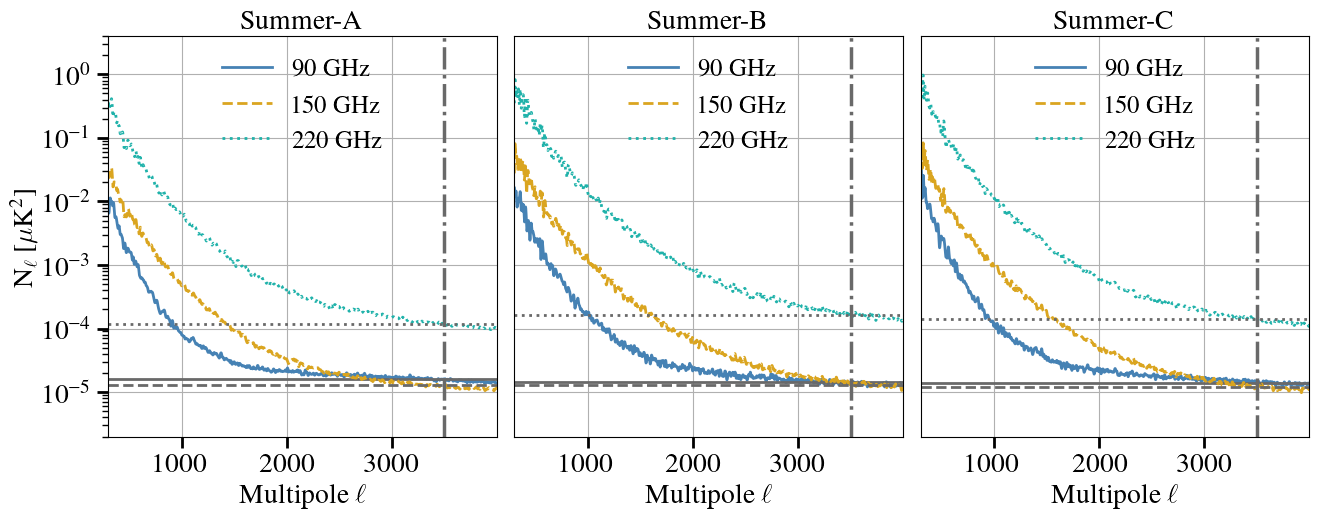

In [15]:
nside=2048
lmax = 2 * nside 
pixwin = hp.pixwin(8192)[:lmax]
ls_arr = ['-', '--', ':']


fig, ax_arr = plt.subplots(1, len(field_arr), sharey=True, figsize=(15.5,5.2))
plt.subplots_adjust(wspace = 0.045)
title_arr = ["Summer-A", "Summer-B", "Summer-C"]


for cntr, field in enumerate(field_arr):
    for frq_cntr, freq in enumerate(freq_arr):    
        blv2 = 1#np.load('/sptlocal/user/kevinlevy/summerfield_lensing/data/beams/compiled_2020_beam_%sghz.npy'%(freq))[:lmax]
        blv4 = 1#np.load('/sptlocal/user/kevinlevy/summerfield_lensing/data/beams/B_ell.npz')[str(freq)][:lmax]
        tf1d = np.load("/sptlocal/user/kevinlevy/summerfield_lensing/sims/mocks/tfs/summer-a/tf1d_%sghz_100sims.npy"%(freq))[:lmax]
          
        curr_binned_nl = np.load('/sptlocal/user/kevinlevy/summerfield_lensing/data/coadds/scandir/%s/spectra/cls_full_coadd_%sghz_%sghz.npy'%(field, freq, freq))
        curr_binned_el = np.arange(len(curr_binned_nl))

        ax_arr[cntr].plot(curr_binned_el, curr_binned_nl/blv4**2/tf1d, color = color_arr[frq_cntr], ls = ls_arr[frq_cntr], lw=2, label = str(freq)+' GHz') 
        ax_arr[cntr].axhline((curr_binned_nl/blv4**2/tf1d)[3500],  ls = ls_arr[frq_cntr], lw=2, color=color_arr[-1])
        print(((curr_binned_nl/blv4**2/tf1d)[3500])**0.5/np.radians(1/60))
    
    ax_arr[cntr].axvline(3500,  ls = "-.", lw=2.5, color=color_arr[-1]) 
    ax_arr[cntr].grid()
    ax_arr[cntr].set_yscale('log')
    ax_arr[cntr].set_xlim(300, 3999) 
    ax_arr[cntr].set_xlabel(r'Multipole $\ell$', fontsize=fontsize)
    ax_arr[cntr].legend(loc = 'upper center', frameon=False, fontsize=fontsize-2)
    ax_arr[cntr].set_title(title_arr[cntr], fontsize=fontsize) 
    ax_arr[cntr].tick_params(which='major', labelsize = fontsize, length = 8, width = 2)
    ax_arr[cntr].tick_params(which='minor', labelsize = fontsize, length = 4, width = 1)
    

    if cntr==0:
        ax_arr[cntr].set_ylim(2e-6, 4e0)
        ax_arr[cntr].set_ylabel(r'N$_{\ell}$ [$\mu$K$^{2}$]', fontsize=fontsize)
    else:
        ax_arr[cntr].tick_params(axis='y', which='major', length = 0, width = 0)
        ax_arr[cntr].tick_params(axis='y', which='minor', length = 0, width = 0)
      
plt.savefig(figures_dir+'data_noise_spectra.pdf', dpi = 250., bbox_inches = 'tight', pad_inches = 0.1)